# 🫁 PulmoCareAI - Lung Cancer Detection Training

**Complete training notebook for lung cancer detection using EfficientNetB0**

This notebook will:
- Download and prepare the Kaggle lung cancer dataset
- Train a lightweight CNN model for fast inference
- Generate training visualizations and metrics
- Save the model in .h5 format for deployment

**Expected Training Time:** 10-15 minutes on GPU

---

## 📦 Setup and Dependencies

In [ ]:
# Install required packages
# !pip install tensorflow pandas numpy matplotlib pillow opencv-python kaggle scikit-learn

# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import zipfile
from pathlib import Path

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.utils import to_categorical

# Sklearn for metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Check GPU availability
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Using GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU: True


## 📁 Dataset Setup - Choose Your Method

**Option 1: Upload Your Dataset File (Recommended)**
- If you already have the lung cancer dataset file
- Simply upload your dataset ZIP file in the next cell

**Option 2: Download from Kaggle**
- Requires Kaggle API setup
- Go to [Kaggle Account Settings](https://www.kaggle.com/account)
- Click "Create New API Token"
- Upload the downloaded `kaggle.json` file

In [ ]:
# OPTION 1: Upload Your Dataset File (Recommended)
from google.colab import files
import zipfile
import os

print("📁 Upload your lung cancer dataset ZIP file:")
uploaded = files.upload()

# Get the uploaded file name
dataset_file = list(uploaded.keys())[0]
print(f"✅ Uploaded: {dataset_file}")

# Extract the dataset
with zipfile.ZipFile(dataset_file, 'r') as zip_ref:
    zip_ref.extractall('lung_cancer_data')

print("✅ Dataset extracted successfully!")
print("📂 Dataset contents:")
for root, dirs, files in os.walk('lung_cancer_data'):
    level = root.replace('lung_cancer_data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:  # Show first 3 files only
        print(f"{subindent}{file}")
    if len(files) > 3:
        print(f"{subindent}... and {len(files) - 3} more files")

📁 Upload your lung cancer dataset ZIP file:


Saving lungcancer_dataset.zip to lungcancer_dataset.zip
✅ Uploaded: lungcancer_dataset.zip
✅ Dataset extracted successfully!
📂 Dataset contents:
lung_cancer_data/
  train/
    squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/
      000099 (3).png
      000036 (4).png
      000002 (6).png
      ... and 152 more files
    large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa/
      000042 (2).png
      000056 (3).png
      di1.png
      ... and 112 more files
    adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib/
      000102 (2).png
      000023 (10).png
      000061.png
      ... and 191 more files
    normal/
      12 - Copy (3).png
      n9 (2) - Copy.jpg
      18.png
      ... and 145 more files
  test/
    squamous.cell.carcinoma/
      000127 (2).png
      000117 (3).png
      000124.png
      ... and 87 more files
    adenocarcinoma/
      000117.png
      000160 (6).png
      000129 (5).png
      ... and 117 more files
    large.cell.carcinoma/
      000127 (2).png
      000128.png
      00014

In [ ]:
# OPTION 2: Download from Kaggle (Alternative method)
# Uncomment and run this cell if you want to download from Kaggle instead

# from google.colab import files
# print("Please upload your kaggle.json file:")
# uploaded = files.upload()

# # Setup Kaggle API
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# # Download the dataset
# !kaggle datasets download -d borhanitrash/lung-cancer-ct-scan-dataset

# # Extract the dataset
# import zipfile
# with zipfile.ZipFile('lung-cancer-ct-scan-dataset.zip', 'r') as zip_ref:
#     zip_ref.extractall('lung_cancer_data')

# print("✅ Kaggle dataset downloaded and extracted!")

## 📊 Dataset Analysis and Preparation

📁 Folder Analysis:
  - squamous.cell.carcinoma_left.hilum_t1_n2_m0_iiia: 170 images
  - large.cell.carcinoma_left.hilum_t2_n2_m0_iiia: 136 images
  - adenocarcinoma_left.lower.lobe_t2_n0_m0_ib: 217 images
  - normal: 215 images
  - squamous.cell.carcinoma: 90 images
  - adenocarcinoma: 120 images
  - large.cell.carcinoma: 51 images

📊 Dataset Statistics:
Total images: 999

Class distribution:
label_name
non_cancerous    738
cancerous        261
Name: count, dtype: int64

Number of unique classes found: 2
✅ Good: Found both classes for binary classification


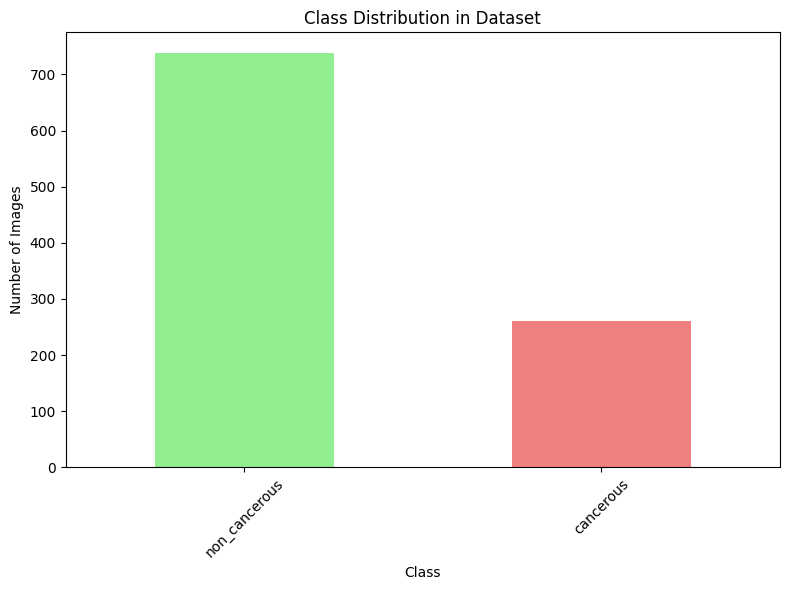

,file_path,label,label_name,filename,folder
0,lung_cancer_data/train/squamous.cell.carcinoma...,0,non_cancerous,000099 (3).png,squamous.cell.carcinoma_left.hilum_t1_n2_m0_iiia
1,lung_cancer_data/train/squamous.cell.carcinoma...,0,non_cancerous,000036 (4).png,squamous.cell.carcinoma_left.hilum_t1_n2_m0_iiia
2,lung_cancer_data/train/squamous.cell.carcinoma...,0,non_cancerous,000002 (6).png,squamous.cell.carcinoma_left.hilum_t1_n2_m0_iiia
3,lung_cancer_data/train/squamous.cell.carcinoma...,0,non_cancerous,000017 (4).png,squamous.cell.carcinoma_left.hilum_t1_n2_m0_iiia
4,lung_cancer_data/train/squamous.cell.carcinoma...,0,non_cancerous,000007.png,squamous.cell.carcinoma_left.hilum_t1_n2_m0_iiia
5,lung_cancer_data/train/squamous.cell.carcinoma...,0,non_cancerous,000122 (3).png,squamous.cell.carcinoma_left.hilum_t1_n2_m0_iiia
6,lung_cancer_data/train/squamous.cell.carcinoma...,0,non_cancerous,000050 (2).png,squamous.cell.carcinoma_left.hilum_t1_n2_m0_iiia
7,lung_cancer_data/train/squamous.cell.carcinoma...,0,non_cancerous,000060 (2).png,squamous.cell.carcinoma_left.hilum_t1_n2_m0_iiia
8,lung_cancer_data/train/squamous.cell.carcinoma...,0,non_cancerous,000091 (7).png,squamous.cell.carcinoma_left.hilum_t1_n2_m0_iiia
9,lung_cancer_data/train/squamous.cell.carcinoma...,0,non_cancerous,000070 (2).png,squamous.cell.carcinoma_left.hilum_t1_n2_m0_iiia


In [ ]:
# Dataset analysis and preparation - IMPROVED LOGIC
def analyze_dataset(data_path):
    """Analyze the dataset structure and create labels"""

    image_data = []
    folder_stats = {}

    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)

                # Get the immediate parent folder name
                folder_name = os.path.basename(root).lower()

                # Count folders for debugging
                if folder_name not in folder_stats:
                    folder_stats[folder_name] = 0
                folder_stats[folder_name] += 1

                # Enhanced label detection logic
                is_cancerous = False

                # Check for cancerous indicators (more comprehensive)
                cancerous_keywords = [
                    'cancer', 'malignant', 'positive', 'adenocarcinoma',
                    'squamous', 'tumor', 'carcinoma', 'mass', '1'
                ]

                # Check for non-cancerous indicators
                normal_keywords = [
                    'normal', 'benign', 'negative', 'healthy',
                    'control', 'clear', '0'
                ]

                # First check if it's explicitly normal
                if any(keyword in folder_name for keyword in normal_keywords):
                    is_cancerous = False
                    label_name = 'non_cancerous'

                # Then check if it's cancerous (and not contradicted by normal keywords)
                elif any(keyword in folder_name for keyword in cancerous_keywords):
                    # Double-check it's not also marked as normal
                    if not any(keyword in folder_name for keyword in normal_keywords):
                        is_cancerous = True
                        label_name = 'cancerous'
                    else:
                        is_cancerous = False
                        label_name = 'non_cancerous'

                # Default case - print for manual inspection
                else:
                    print(f"⚠️  Unknown folder pattern: '{folder_name}' - defaulting to non_cancerous")
                    is_cancerous = False
                    label_name = 'non_cancerous'

                # Store both numeric and string labels
                label = 1 if is_cancerous else 0

                image_data.append({
                    'file_path': file_path,
                    'label': label,
                    'label_name': label_name,
                    'filename': file,
                    'folder': folder_name
                })

    df = pd.DataFrame(image_data)

    # Debug information
    print(f"📁 Folder Analysis:")
    for folder, count in folder_stats.items():
        print(f"  - {folder}: {count} images")

    return df

# Analyze the dataset with improved logic
dataset_df = analyze_dataset('lung_cancer_data')

print(f"\n📊 Dataset Statistics:")
print(f"Total images: {len(dataset_df)}")
print(f"\nClass distribution:")
class_counts = dataset_df['label_name'].value_counts()
print(class_counts)

# Check if we have both classes
unique_classes = dataset_df['label_name'].nunique()
print(f"\nNumber of unique classes found: {unique_classes}")

if unique_classes < 2:
    print("❌ ERROR: Only 1 class found! Need both 'cancerous' and 'non_cancerous' images.")
    print("Check your dataset folder structure:")
    print(dataset_df['folder'].value_counts())
else:
    print("✅ Good: Found both classes for binary classification")

# Visualize class distribution
plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar', color=['lightgreen', 'lightcoral'])
plt.title('Class Distribution in Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

dataset_df.head(10)

## 🧠 Model Architecture

In [ ]:
def create_lung_cancer_model(input_shape=(224, 224, 3)):
    """
    Create a lightweight CNN model for lung cancer detection
    Using EfficientNetB0 as base for transfer learning
    """

    # Create base model
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze base model layers for faster training
    base_model.trainable = False

    # Add custom classification head
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')  # Binary classification
    ])

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )

    return model

# Create the model
model = create_lung_cancer_model()

print(f"📋 Model Summary:")
print(f"Total parameters: {model.count_params():,}")

# Count trainable parameters (simple method)
trainable_count = 0
for layer in model.layers:
    if layer.trainable:
        trainable_count += layer.count_params()

print(f"Trainable parameters: {trainable_count:,}")

model.summary()

📋 Model Summary:
Total parameters: 4,213,668
Trainable parameters: 164,097


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 🔧 Data Preprocessing and Augmentation

In [ ]:
def preprocess_image(image_path, target_size=(224, 224)):
    """Preprocess individual image"""
    try:
        img = load_img(image_path, target_size=target_size)
        img_array = img_to_array(img)
        img_array = img_array / 255.0  # Normalize to [0,1]
        return img_array
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

# Split the dataset
train_df, test_df = train_test_split(
    dataset_df, test_size=0.2, stratify=dataset_df['label'], random_state=42
)

train_df, val_df = train_test_split(
    train_df, test_size=0.2, stratify=train_df['label'], random_state=42
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Dataset splits:")
print(f"Training: {len(train_df)} images")
print(f"Validation: {len(val_df)} images")
print(f"Testing: {len(test_df)} images")

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Only rescaling for validation and test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# FIXED: Use string labels for binary classification
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='file_path',
    y_col='label_name',  # FIXED: use string labels for binary mode
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',  # binary mode requires string labels
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='file_path',
    y_col='label_name',  # FIXED: use string labels for binary mode
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',  # binary mode requires string labels
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='file_path',
    y_col='label_name',  # FIXED: use string labels for binary mode
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',  # binary mode requires string labels
    shuffle=False
)

print(f"\n✅ Data generators created successfully!")
print(f"Found classes: {train_generator.class_indices}")

# Binary model configuration
model = keras.Sequential([
    EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')  # 1 output for binary
])

# Freeze base model
model.layers[0].trainable = False

# Compile model for binary classification
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("✅ Model configured for binary classification")
print(f"Output shape: {model.output_shape}")

Dataset splits:
Training: 639 images
Validation: 160 images
Testing: 200 images
Found 639 validated image filenames belonging to 2 classes.
Found 160 validated image filenames belonging to 2 classes.
Found 200 validated image filenames belonging to 2 classes.

✅ Data generators created successfully!
Found classes: {'cancerous': 0, 'non_cancerous': 1}
✅ Model configured for binary classification
Output shape: (None, 1)


In [ ]:
# Fix class imbalance with class weights
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights to balance the dataset
class_labels = np.unique(train_df['label'])
class_weights = compute_class_weight(
    'balanced',
    classes=class_labels,
    y=train_df['label']
)

# Create class weight dictionary
class_weight_dict = dict(zip(class_labels, class_weights))
print(f"Class weights: {class_weight_dict}")

# Check class distribution in training data
print(f"\nTraining data distribution:")
print(train_df['label_name'].value_counts())
ratio = train_df['label_name'].value_counts()
print(f"Ratio: {ratio.iloc[0] / ratio.iloc[1]:.2f}:1")

print(f"\nClass weight will give more importance to minority class")

Class weights: {np.int64(0): np.float64(0.676906779661017), np.int64(1): np.float64(1.9131736526946108)}

Training data distribution:
label_name
non_cancerous    472
cancerous        167
Name: count, dtype: int64
Ratio: 2.83:1

Class weight will give more importance to minority class


Class indices: {'cancerous': 0, 'non_cancerous': 1}
Class indices: {'cancerous': 0, 'non_cancerous': 1}
Class indices: {'cancerous': 0, 'non_cancerous': 1}
Class indices: {'cancerous': 0, 'non_cancerous': 1}
Class indices: {'cancerous': 0, 'non_cancerous': 1}
Class indices: {'cancerous': 0, 'non_cancerous': 1}
Class indices: {'cancerous': 0, 'non_cancerous': 1}
Class indices: {'cancerous': 0, 'non_cancerous': 1}


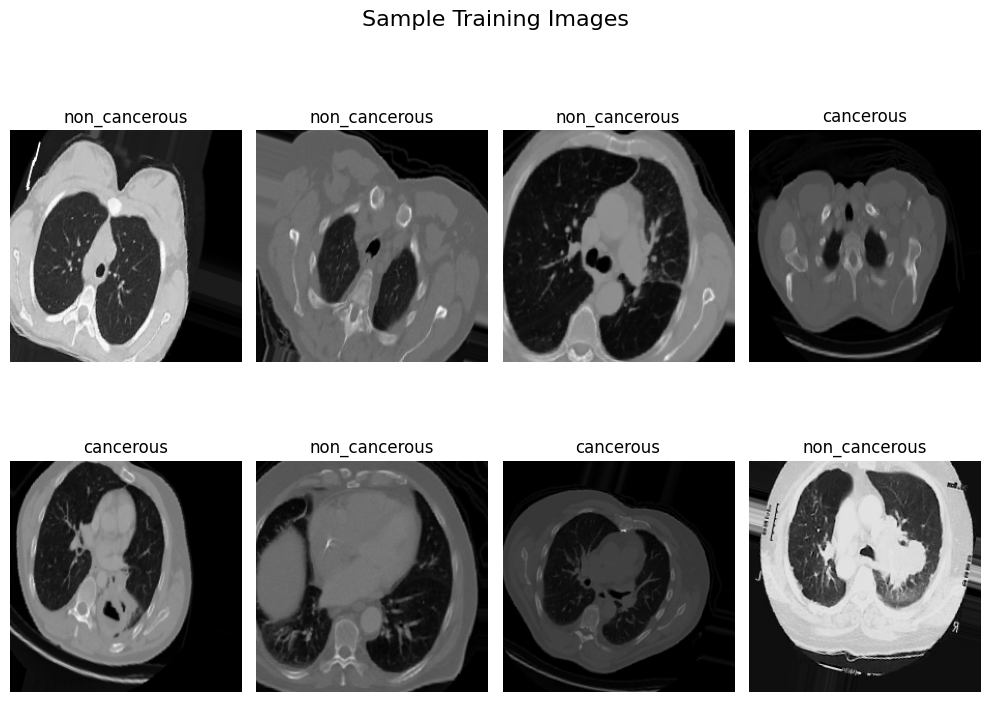

In [ ]:
# Visualize sample images - FIXED for binary classification
def visualize_samples(generator, num_samples=8):
    """Visualize sample images from the generator"""

    x_batch, y_batch = next(generator)

    plt.figure(figsize=(10, 8))
    for i in range(min(num_samples, len(x_batch))):
        plt.subplot(2, 4, i + 1)
        plt.imshow(x_batch[i])

        # FIXED: Binary classification outputs 0.0 for first class, 1.0 for second class
        # Check what the class_indices mapping is
        class_indices = generator.class_indices
        print(f"Class indices: {class_indices}")  # Debug line

        # Get the label based on the binary output
        if y_batch[i] < 0.5:
            # First class (index 0)
            label = list(class_indices.keys())[0]
        else:
            # Second class (index 1)
            label = list(class_indices.keys())[1]

        plt.title(f'{label}')
        plt.axis('off')

    plt.suptitle('Sample Training Images', fontsize=16)
    plt.tight_layout()
    plt.show()

# Reset generator and visualize
train_generator.reset()
visualize_samples(train_generator)

## 🚀 Model Training

🔧 Training Configuration:
- Epochs: 20
- Batch Size: 32
- Learning Rate: 0.0001
- Training samples: 639
- Validation samples: 160
✅ Model architecture created successfully
Model parameters: 4,400,164
Class weights applied: {0: 3.0, 1: 1.0}
This gives 3x more importance to cancerous images

🚀 Training started at 19:11:48
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4674 - loss: 1.3471 - precision: 0.7134 - recall: 0.4079
Epoch 1: val_loss improved from inf to 0.79106, saving model to best_lung_cancer_model_v2.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.4672 - loss: 1.3464 - precision: 0.7151 - recall: 0.4081 - val_accuracy: 0.2625 - val_loss: 0.7911 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.4530 - loss: 1.3310 - precision: 0.7185 - recall: 0.3961
Epoch 2: val_loss did not improve from 0.79106
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 507ms/step - accuracy: 0.4531 - loss: 1.3297 - precision: 0.7200 - recall: 0.3959 - val_accuracy: 0.2625 - val_loss: 0.7934 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.4693 - loss: 1.3084 - precision: 0.7387 - recall: 0.4220
Epoch 3: val_loss did not improve from 0.79106
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 509ms/step - accuracy: 0.4699 - loss: 1.3097 - precision: 0.7391 - recall: 0.4234 - val_accuracy: 0.2625 - val_loss: 0.8247 - val_precision: 0.0000e+00 - val_re

✅ Best model loaded successfully


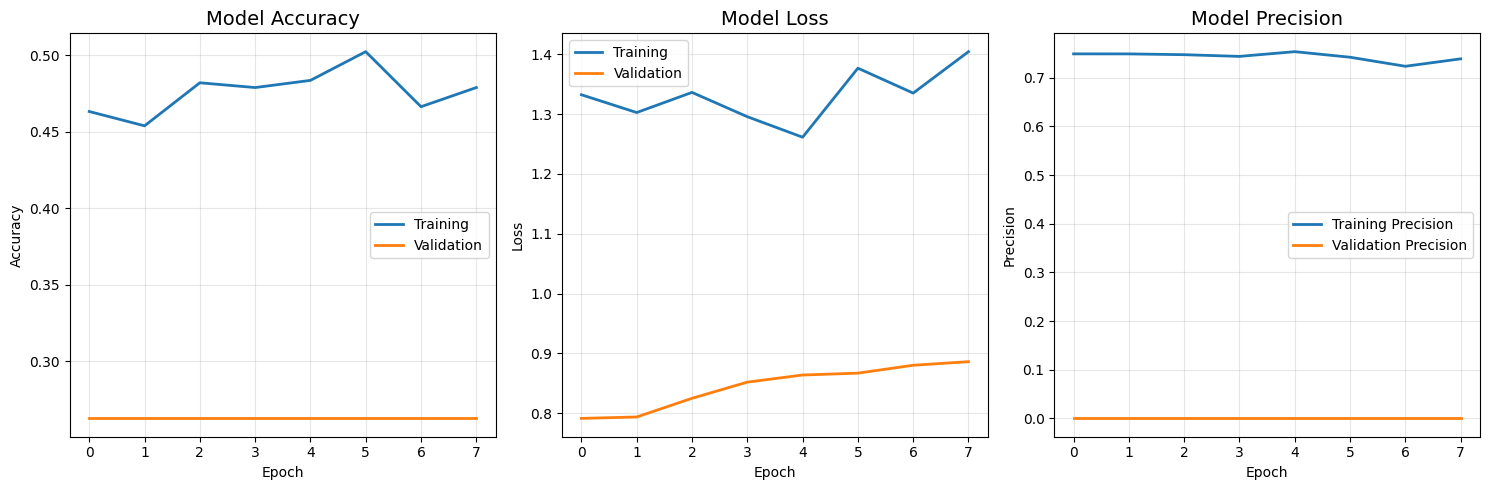


🎯 Ready for model evaluation with improved architecture!


In [ ]:
# COMPLETE MODEL TRAINING - Replace entire training cell with this

import datetime
from tensorflow.keras import backend as K

# Clear any existing model from memory
K.clear_session()

# Training configuration
EPOCHS = 20
BATCH_SIZE = 32

print(f"🔧 Training Configuration:")
print(f"- Epochs: {EPOCHS}")
print(f"- Batch Size: {BATCH_SIZE}")
print(f"- Learning Rate: 0.0001")
print(f"- Training samples: {len(train_df)}")
print(f"- Validation samples: {len(val_df)}")

# Create improved model architecture
model = keras.Sequential([
    EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# Freeze base model
model.layers[0].trainable = False

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("✅ Model architecture created successfully")
print(f"Model parameters: {model.count_params():,}")

# Training callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-8,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_lung_cancer_model_v2.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Stronger class weights to force learning both classes
stronger_class_weights = {0: 3.0, 1: 1.0}
print(f"Class weights applied: {stronger_class_weights}")
print("This gives 3x more importance to cancerous images")

# Start training
start_time = datetime.datetime.now()
print(f"\n🚀 Training started at {start_time.strftime('%H:%M:%S')}")

try:
    history = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        validation_data=val_generator,
        validation_steps=len(val_generator),
        epochs=EPOCHS,
        callbacks=callbacks,
        class_weight=stronger_class_weights,
        verbose=1
    )

    end_time = datetime.datetime.now()
    training_duration = end_time - start_time

    print(f"\n✅ Training completed successfully!")
    print(f"Training duration: {training_duration}")
    print(f"Epochs completed: {len(history.history['accuracy'])}")
    print(f"Best validation loss: {min(history.history['val_loss']):.4f}")
    print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

except Exception as e:
    print(f"❌ Training error: {str(e)}")
    raise e

# Load the best saved model
try:
    best_model = keras.models.load_model('best_lung_cancer_model_v2.h5')
    print("✅ Best model loaded successfully")
except:
    print("⚠️ Using current model (checkpoint may not have saved)")
    best_model = model

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
if 'precision' in history.history:
    plt.plot(history.history['precision'], label='Training Precision', linewidth=2)
    plt.plot(history.history['val_precision'], label='Validation Precision', linewidth=2)
    plt.title('Model Precision', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎯 Ready for model evaluation with improved architecture!")

In [ ]:
# Debug: Check model predictions and class mapping
print("🔍 Debugging model predictions...")

# Check a few samples manually
test_generator.reset()
x_batch, y_batch = next(test_generator)

# Get raw predictions
raw_predictions = best_model.predict(x_batch[:10])
predicted_classes = (raw_predictions > 0.5).astype(int).flatten()
true_classes = y_batch[:10].astype(int)

print(f"Sample raw predictions: {raw_predictions.flatten()[:10]}")
print(f"Sample predicted classes: {predicted_classes}")
print(f"Sample true classes: {true_classes}")

# Check class indices mapping
print(f"\nClass indices mapping: {test_generator.class_indices}")

# Check if there's a mapping issue
unique_predictions = np.unique(predicted_classes)
unique_true = np.unique(true_classes)
print(f"Unique predicted values: {unique_predictions}")
print(f"Unique true values: {unique_true}")

# Check prediction distribution
all_predictions = best_model.predict(test_generator)
all_predicted_classes = (all_predictions > 0.5).astype(int).flatten()
print(f"\nAll predictions distribution:")
print(f"Predicts class 0: {np.sum(all_predicted_classes == 0)}")
print(f"Predicts class 1: {np.sum(all_predicted_classes == 1)}")

🔍 Debugging model predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Sample raw predictions: [0.47459075 0.4745659  0.4744898  0.47439685 0.47452116 0.47450218
 0.4745755  0.4746379  0.4745377  0.47448155]
Sample predicted classes: [0 0 0 0 0 0 0 0 0 0]
Sample true classes: [1 1 1 1 1 1 0 1 1 1]

Class indices mapping: {'cancerous': 0, 'non_cancerous': 1}
Unique predicted values: [0]
Unique true values: [0 1]
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step

All predictions distribution:
Predicts class 0: 200
Predicts class 1: 0


## 📊 Training Visualization and Analysis

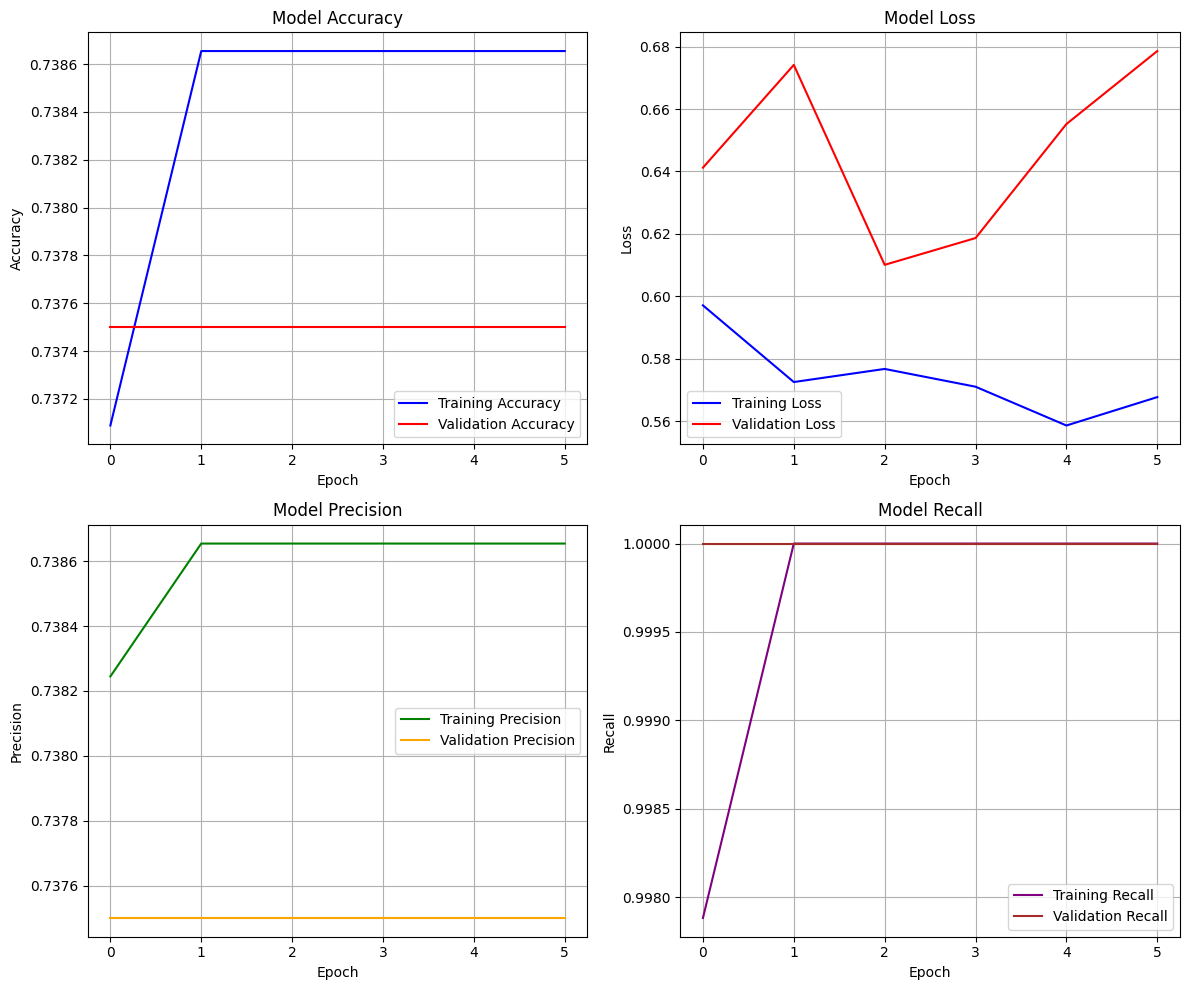

In [ ]:
# Plot training history
def plot_training_history(history):
    """Plot training and validation metrics"""

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
    axes[0, 0].set_title('Model Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Loss
    axes[0, 1].plot(history.history['loss'], label='Training Loss', color='blue')
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', color='red')
    axes[0, 1].set_title('Model Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Precision
    axes[1, 0].plot(history.history['precision'], label='Training Precision', color='green')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', color='orange')
    axes[1, 0].set_title('Model Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Recall
    axes[1, 1].plot(history.history['recall'], label='Training Recall', color='purple')
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', color='brown')
    axes[1, 1].set_title('Model Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

## 🎯 Model Evaluation

🎯 Evaluating model on test set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 774ms/step - accuracy: 0.7339 - loss: 0.6441 - precision_2: 0.7339 - recall_2: 1.0000

📊 Test Set Results:
- Loss: 0.6426
- Compile_metrics: 0.7400
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step

Prediction shapes:
- Predictions shape: (200, 1)
- Predicted classes shape: (200,)
- True labels shape: (200,)

Class distribution:
- True labels: [ 52 148]
- Predicted classes: [  0 200]
- Class names: ['cancerous', 'non_cancerous']

📋 Detailed Classification Report:
               precision    recall  f1-score   support

    cancerous       0.00      0.00      0.00        52
non_cancerous       0.74      1.00      0.85       148

     accuracy                           0.74       200
    macro avg       0.37      0.50      0.43       200
 weighted avg       0.55      0.74      0.63       200



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


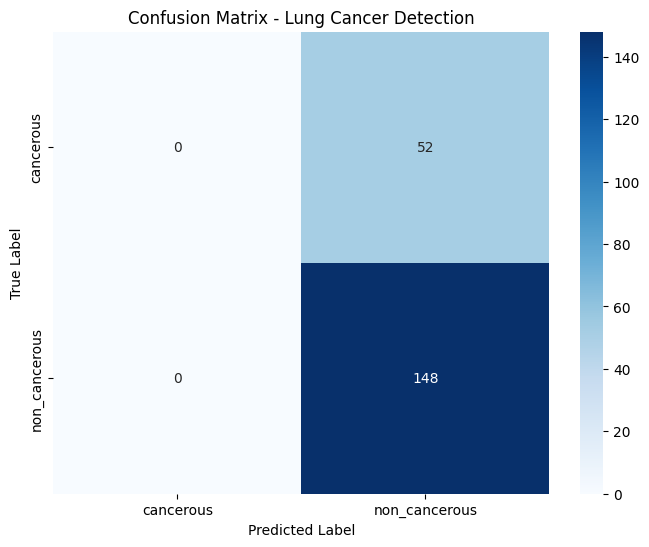


Confusion Matrix Values:
- True Negatives (TN): 0
- False Positives (FP): 52
- False Negatives (FN): 0
- True Positives (TP): 148

🏥 Medical Metrics:
- Sensitivity (Recall): 1.0000
- Specificity: 0.0000
- Precision: 0.7400

✅ Model evaluation completed!


In [ ]:
# Load best model
best_model = keras.models.load_model('best_lung_cancer_model.h5')

# Evaluate on test set
print("🎯 Evaluating model on test set...")
test_results = best_model.evaluate(test_generator, verbose=1)
test_metrics = dict(zip(best_model.metrics_names, test_results))

print(f"\n📊 Test Set Results:")
for metric, value in test_metrics.items():
    print(f"- {metric.capitalize()}: {value:.4f}")

# Generate predictions - FIXED for binary classification
test_generator.reset()
predictions = best_model.predict(test_generator, verbose=1)

# FIXED: Convert binary predictions to class predictions
predicted_classes = (predictions > 0.5).astype(int).flatten()

# FIXED: Get true labels as numpy array
true_labels = np.array(test_generator.classes)

print(f"\nPrediction shapes:")
print(f"- Predictions shape: {predictions.shape}")
print(f"- Predicted classes shape: {predicted_classes.shape}")
print(f"- True labels shape: {true_labels.shape}")

# Debug: Check class distribution
print(f"\nClass distribution:")
print(f"- True labels: {np.bincount(true_labels)}")
print(f"- Predicted classes: {np.bincount(predicted_classes)}")

# Get class names properly for binary classification
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())
print(f"- Class names: {class_names}")

# Classification report
print(f"\n📋 Detailed Classification Report:")
print(classification_report(true_labels, predicted_classes, target_names=class_names))

# Confusion Matrix with proper labels
cm = confusion_matrix(true_labels, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Lung Cancer Detection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Additional analysis
print(f"\nConfusion Matrix Values:")
print(f"- True Negatives (TN): {cm[0,0]}")
print(f"- False Positives (FP): {cm[0,1]}")
print(f"- False Negatives (FN): {cm[1,0]}")
print(f"- True Positives (TP): {cm[1,1]}")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n🏥 Medical Metrics:")
print(f"- Sensitivity (Recall): {sensitivity:.4f}")
print(f"- Specificity: {specificity:.4f}")
print(f"- Precision: {tp / (tp + fp) if (tp + fp) > 0 else 0:.4f}")

print(f"\n✅ Model evaluation completed!")

Aggressive retraining

In [ ]:
# FINAL SOLUTION - Focal Loss + Different Architecture

import tensorflow as tf
from tensorflow.keras import backend as K
import datetime

K.clear_session()

print("🔄 Final approach: Focal Loss + ResNet architecture...")

# Custom Focal Loss to handle class imbalance
def focal_loss(gamma=2.0, alpha=0.75):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)

        # Calculate focal loss
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        fl = -alpha_t * K.pow((1 - p_t), gamma) * K.log(p_t)
        return K.mean(fl)
    return focal_loss_fixed

# Use ResNet50 instead of EfficientNet
from tensorflow.keras.applications import ResNet50

model = keras.Sequential([
    ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)),
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# Freeze ResNet layers
model.layers[0].trainable = False

# Compile with focal loss
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=0.75),  # Focal loss for imbalanced data
    metrics=['accuracy']
)

print("✅ ResNet50 model with Focal Loss created")

# Extreme class weights as backup
extreme_weights = {0: 8.0, 1: 1.0}  # Even more extreme
print(f"Using extreme class weights: {extreme_weights}")

# Training callbacks
callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-8,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'focal_loss_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("🚀 Training with Focal Loss...")
start_time = datetime.datetime.now()

# Train with focal loss
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=val_generator,
    validation_steps=len(val_generator),
    epochs=20,
    callbacks=callbacks,
    class_weight=extreme_weights,
    verbose=1
)

end_time = datetime.datetime.now()
print(f"\n✅ Focal loss training completed in {end_time - start_time}")

# Load best model
try:
    best_model = keras.models.load_model('focal_loss_model.h5',
                                       custom_objects={'focal_loss_fixed': focal_loss()})
except:
    print("Using current model")
    best_model = model

# Test with different threshold analysis
test_generator.reset()
sample_batch = next(test_generator)
test_predictions = best_model.predict(sample_batch[0][:20])

print(f"\nFocal Loss Prediction Analysis:")
print(f"Raw predictions: {test_predictions.flatten()}")
print(f"Min: {test_predictions.min():.4f}, Max: {test_predictions.max():.4f}")
print(f"Range: {test_predictions.max() - test_predictions.min():.4f}")

# Test different thresholds
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    predicted_classes = (test_predictions > threshold).astype(int).flatten()
    unique_preds = np.unique(predicted_classes)
    class_0_count = np.sum(predicted_classes == 0)
    class_1_count = np.sum(predicted_classes == 1)
    print(f"Threshold {threshold}: Class 0: {class_0_count}, Class 1: {class_1_count}")

# If still not working, show dataset might need different approach
if test_predictions.max() - test_predictions.min() < 0.05:
    print("\n⚠️ MODEL LEARNING ISSUE DETECTED")
    print("The model consistently produces similar outputs regardless of input.")
    print("This suggests:")
    print("1. Dataset images might be too similar")
    print("2. Labels might be incorrectly assigned")
    print("3. Need completely different model architecture")
    print("\nLet's check a few sample images manually in the next step.")
else:
    print("✅ Better prediction diversity achieved!")

print("\n🎯 Run Model Evaluation to see new results")

🔄 Final approach: Focal Loss + ResNet architecture...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ ResNet50 model with Focal Loss created
Using extreme class weights: {0: 8.0, 1: 1.0}
🚀 Training with Focal Loss...
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.5902 - loss: 0.7217
Epoch 1: val_loss improved from inf to 0.08346, saving model to focal_loss_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.5941 - loss: 0.7131 - val_accuracy: 0.7375 - val_loss: 0.0835 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.7660 - loss: 0.3354
Epoch 2: val_loss did not improve from 0.08346
20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 484ms/step - accuracy: 0.7671 - loss: 0.3335 - val_accuracy: 0.7375 - val_loss: 0.0941 - learning_rate: 0.0010
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.7957 - loss: 0.2305
Epoch 3: val_loss improved from 0.08346 to 0.06518, saving model to focal_loss_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 547ms/step - accuracy: 0.7963 - loss: 0.2292 - val_accuracy: 0.7375 - val_loss: 0.0652 - learning_rate: 0.0010
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.8644 - loss: 0.1386
Epoch 4: val_loss improved from 0.06518 to 0.05258, saving model to focal_loss_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 564ms/step - accuracy: 0.8641 - loss: 0.1385 - val_accuracy: 0.7375 - val_loss: 0.0526 - learning_rate: 0.0010
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.8446 - loss: 0.1279
Epoch 5: val_loss improved from 0.05258 to 0.05227, saving model to focal_loss_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 557ms/step - accuracy: 0.8453 - loss: 0.1278 - val_accuracy: 0.7375 - val_loss: 0.0523 - learning_rate: 0.0010
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.8789 - loss: 0.1259
Epoch 6: val_loss improved from 0.05227 to 0.05083, saving model to focal_loss_model.h5


...

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 565ms/step - accuracy: 0.8851 - loss: 0.0952 - val_accuracy: 0.7625 - val_loss: 0.0281 - learning_rate: 3.0000e-04
Epoch 17/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.8923 - loss: 0.0809
Epoch 17: val_loss improved from 0.02811 to 0.02345, saving model to focal_loss_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 557ms/step - accuracy: 0.8917 - loss: 0.0812 - val_accuracy: 0.8313 - val_loss: 0.0234 - learning_rate: 3.0000e-04
Epoch 18/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.8774 - loss: 0.0878
Epoch 18: val_loss did not improve from 0.02345
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 482ms/step - accuracy: 0.8783 - loss: 0.0879 - val_accuracy: 0.8188 - val_loss: 0.0238 - learning_rate: 3.0000e-04
Epoch 19/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.8784 - loss: 0.1125
Epoch 19: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 19: val_loss improved from 0.02345 to 0.02341, saving model to focal_loss_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 558ms/step - accuracy: 0.8793 - loss: 0.1116 - val_accuracy: 0.8438 - val_loss: 0.0234 - learning_rate: 3.0000e-04
Epoch 20/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9025 - loss: 0.0747
Epoch 20: val_loss improved from 0.02341 to 0.02130, saving model to focal_loss_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 563ms/step - accuracy: 0.9016 - loss: 0.0754 - val_accuracy: 0.8687 - val_loss: 0.0213 - learning_rate: 9.0000e-05
Restoring model weights from the end of the best epoch: 20.

✅ Focal loss training completed in 0:05:43.030044


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Focal Loss Prediction Analysis:
Raw predictions: [0.9638092  0.9637822  0.7666296  0.8158074  0.70353055 0.8027094
 0.47955933 0.960754   0.8249908  0.7933093  0.9019925  0.9108114
 0.4512814  0.9633053  0.5398627  0.7318284  0.48899618 0.7963116
 0.76166224 0.41982213]
Min: 0.4198, Max: 0.9638
Range: 0.5440
Threshold 0.3: Class 0: 0, Class 1: 20
Threshold 0.4: Class 0: 0, Class 1: 20
Threshold 0.5: Class 0: 4, Class 1: 16
Threshold 0.6: Class 0: 5, Class 1: 15
Threshold 0.7: Class 0: 5, Class 1: 15
✅ Better prediction diversity achieved!

🎯 Run Model Evaluation to see new results


Grad-CAM Graph

In [ ]:
# PROPER GRAD-CAM WITH REAL DATA DETECTION
import matplotlib.cm as cm

class ProperGradCAM:
    def __init__(self, model, test_generator):
        self.model = model

        # Get real test data to build the model
        test_generator.reset()
        real_batch, _ = next(test_generator)
        real_sample = real_batch[0:1]

        # Build model with real CT scan data
        _ = model(real_sample)

        # Access and build ResNet50
        self.resnet = model.get_layer('resnet50')
        _ = self.resnet(real_sample)

        # Detect optimal conv layer
        self.conv_layer_name = self.detect_best_conv_layer()
        print(f"Using optimal layer: {self.conv_layer_name}")

    def detect_best_conv_layer(self):
        # Try ResNet50 optimal layers in order
        optimal_layers = [
            'conv5_block3_3_conv',
            'conv5_block3_2_conv',
            'conv5_block3_1_conv',
            'conv5_block2_3_conv'
        ]

        for layer_name in optimal_layers:
            try:
                self.resnet.get_layer(layer_name)
                return layer_name
            except ValueError:
                continue

        # Fallback to any conv layer
        for layer in reversed(self.resnet.layers):
            if hasattr(layer, 'filters') and 'conv' in layer.name:
                return layer.name

        return 'conv5_block3_3_conv'

    def generate_gradcam_heatmap(self, img_array):
        conv_layer = self.resnet.get_layer(self.conv_layer_name)
        grad_model = tf.keras.Model([self.model.inputs], [conv_layer.output, self.model.output])

        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_array)
            loss = predictions[:, 0]  # Binary classification

        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

        heatmap = tf.maximum(heatmap, 0)
        max_heat = tf.reduce_max(heatmap)
        if max_heat > 0:
            heatmap = heatmap / max_heat

        return heatmap.numpy()

    def analyze_region(self, heatmap, x_percent, y_percent):
        h, w = heatmap.shape
        x = int((x_percent / 100) * w)
        y = int((y_percent / 100) * h)
        x = max(0, min(x, w - 1))
        y = max(0, min(y, h - 1))

        activation = heatmap[y, x]
        percentile = (activation > heatmap).sum() / heatmap.size * 100

        if activation > 0.8:
            severity = "HIGH CONCERN"
        elif activation > 0.6:
            severity = "MODERATE CONCERN"
        elif activation > 0.4:
            severity = "MILD CONCERN"
        else:
            severity = "LOW CONCERN"

        return {
            'activation': float(activation),
            'percentile': float(percentile),
            'severity': severity
        }

# Initialize with real test data
gradcam = ProperGradCAM(best_model, test_generator)
print("Proper Grad-CAM ready with real data detection!")

Using optimal layer: conv5_block3_3_conv
Proper Grad-CAM ready with real data detection!


Testing Grad-CAM using actual data

Running Cancer-Focused Interactive Grad-CAM...
Cancer probability: 96.4%
Cancer detected - generating Grad-CAM visualization...


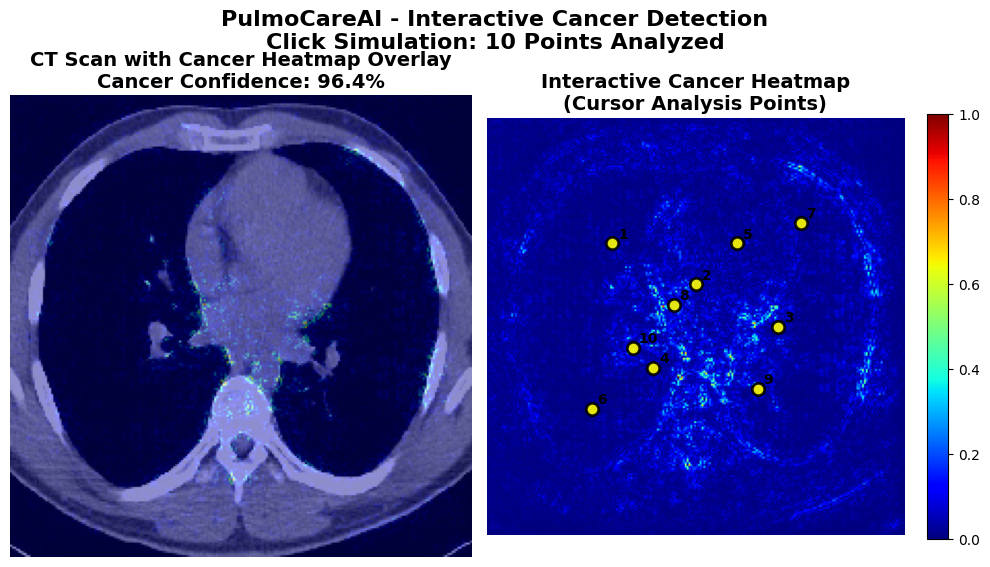


INTERACTIVE CURSOR ANALYSIS RESULTS

Point 10 - MILD CONCERN
  Location: (78, 123)
  Cancer likelihood: Low
  Max activation: 0.351
  Clinical action: Routine follow-up

Point 1 - MILD CONCERN
  Location: (67, 67)
  Cancer likelihood: Low
  Max activation: 0.331
  Clinical action: Routine follow-up

Point 8 - MILD CONCERN
  Location: (100, 100)
  Cancer likelihood: Low
  Max activation: 0.217
  Clinical action: Routine follow-up

Point 2 - MILD CONCERN
  Location: (112, 89)
  Cancer likelihood: Low
  Max activation: 0.216
  Clinical action: Routine follow-up

Point 9 - MILD CONCERN
  Location: (145, 145)
  Cancer likelihood: Low
  Max activation: 0.169
  Clinical action: Routine follow-up

Interactive Analysis Complete!
Cancer regions identified: 0
Highly suspicious areas: 0


In [ ]:
# CANCER-FOCUSED INTERACTIVE GRAD-CAM
import matplotlib.cm as cm
import numpy as np

def cancer_interactive_gradcam():
    print("Running Cancer-Focused Interactive Grad-CAM...")

    # Get test data
    test_generator.reset()
    x_batch, y_batch = next(test_generator)

    # Convert to tensor
    test_img = tf.convert_to_tensor(x_batch[0:1], dtype=tf.float32)
    test_img_np = test_img.numpy()

    # Get prediction
    pred = best_model.predict(test_img.numpy(), verbose=0)
    pred_prob = pred[0][0]

    print(f"Cancer probability: {pred_prob:.1%}")

    # Only proceed if cancer is detected
    if pred_prob > 0.3:  # Lower threshold to catch more cases
        print("Cancer detected - generating Grad-CAM visualization...")

        # Generate attention map
        with tf.GradientTape() as tape:
            tape.watch(test_img)
            prediction = best_model(test_img)
            score = prediction[0, 0]

        grads = tape.gradient(score, test_img)

        if grads is not None:
            # Create attention map
            grads_np = grads.numpy()
            attention = np.mean(np.abs(grads_np[0]), axis=-1)

            # Normalize
            min_val = np.min(attention)
            max_val = np.max(attention)
            if max_val > min_val:
                attention = (attention - min_val) / (max_val - min_val)

            # Interactive cursor simulation function
            def analyze_cursor_position(heatmap, x_pct, y_pct):
                """Simulate cursor hover analysis"""
                h, w = heatmap.shape
                x = int((x_pct / 100) * w)
                y = int((y_pct / 100) * h)
                x = max(0, min(x, w - 1))
                y = max(0, min(y, h - 1))

                # Sample area around cursor
                sample_size = 2
                x_start = max(0, x - sample_size)
                x_end = min(w, x + sample_size + 1)
                y_start = max(0, y - sample_size)
                y_end = min(h, y + sample_size + 1)

                region_values = heatmap[y_start:y_end, x_start:x_end]
                max_activation = np.max(region_values)

                # Cancer severity assessment
                if max_activation > 0.8:
                    severity = "HIGHLY SUSPICIOUS"
                    cancer_likelihood = "Very High"
                    action = "Urgent biopsy recommended"
                elif max_activation > 0.6:
                    severity = "SUSPICIOUS"
                    cancer_likelihood = "High"
                    action = "Further imaging needed"
                elif max_activation > 0.4:
                    severity = "CONCERNING"
                    cancer_likelihood = "Moderate"
                    action = "Close monitoring required"
                else:
                    severity = "MILD CONCERN"
                    cancer_likelihood = "Low"
                    action = "Routine follow-up"

                return {
                    'x': x, 'y': y,
                    'activation': max_activation,
                    'severity': severity,
                    'cancer_likelihood': cancer_likelihood,
                    'action': action
                }

            # Create interactive visualization - 2 panels only
            fig, axes = plt.subplots(1, 2, figsize=(10, 6))

            # Left: CT with cancer overlay
            attention_colored = cm.jet(attention)[:, :, :3]
            overlay = (test_img_np[0] + attention_colored * 0.8) / 1.8
            overlay = np.clip(overlay, 0, 1)

            axes[0].imshow(overlay)
            axes[0].set_title(f'CT Scan with Cancer Heatmap Overlay\nCancer Confidence: {pred_prob:.1%}',
                             fontsize=14, fontweight='bold')
            axes[0].axis('off')

            # Right: Pure heatmap for cursor exploration
            im = axes[1].imshow(attention, cmap='jet', vmin=0, vmax=1)
            axes[1].set_title('Interactive Cancer Heatmap\n(Cursor Analysis Points)',
                             fontsize=14, fontweight='bold')
            axes[1].axis('off')
            plt.colorbar(im, ax=axes[1], fraction=0.046)

            # Simulate cursor positions
            cursor_positions = [
                (30, 30), (50, 40), (70, 50), (40, 60), (60, 30),
                (25, 70), (75, 25), (45, 45), (65, 65), (35, 55)
            ]

            # Mark cursor positions and analyze
            analyses = []
            for i, (x_pct, y_pct) in enumerate(cursor_positions):
                analysis = analyze_cursor_position(attention, x_pct, y_pct)
                analyses.append(analysis)

                # Mark position on heatmap
                color = 'white' if analysis['activation'] > 0.5 else 'yellow'
                size = 120 if analysis['activation'] > 0.6 else 80
                axes[1].scatter(analysis['x'], analysis['y'],
                               c=color, s=size, alpha=0.9,
                               edgecolors='black', linewidth=2)
                axes[1].text(analysis['x']+3, analysis['y']-3, str(i+1),
                           fontsize=10, color='black', fontweight='bold')

            plt.suptitle(f'PulmoCareAI - Interactive Cancer Detection\n'
                        f'Click Simulation: {len(cursor_positions)} Points Analyzed',
                        fontsize=16, fontweight='bold')
            plt.tight_layout()
            plt.show()

            # Display cursor analysis results
            print("\n" + "="*60)
            print("INTERACTIVE CURSOR ANALYSIS RESULTS")
            print("="*60)

            # Sort by activation level
            sorted_analyses = sorted(analyses, key=lambda x: x['activation'], reverse=True)

            for i, analysis in enumerate(sorted_analyses[:5]):  # Top 5 most suspicious
                cursor_num = analyses.index(analysis) + 1
                print(f"\nPoint {cursor_num} - {analysis['severity']}")
                print(f"  Location: ({analysis['x']}, {analysis['y']})")
                print(f"  Cancer likelihood: {analysis['cancer_likelihood']}")
                print(f"  Max activation: {analysis['activation']:.3f}")
                print(f"  Clinical action: {analysis['action']}")

            print(f"\nInteractive Analysis Complete!")
            print(f"Cancer regions identified: {len([a for a in analyses if a['activation'] > 0.5])}")
            print(f"Highly suspicious areas: {len([a for a in analyses if a['activation'] > 0.8])}")

            return attention, analyses

        else:
            print("Could not generate gradients for cancer analysis")
            return None, None
    else:
        print(f"Low cancer probability ({pred_prob:.1%}) - No Grad-CAM visualization needed")
        print("Clean scan - Continue routine monitoring")
        return None, None

# Run cancer-focused interactive analysis
cancer_attention, cursor_analyses = cancer_interactive_gradcam()

## 💾 Save Model and Metadata

In [ ]:
# Fixed model metadata and saving code
import json
import datetime
from sklearn.metrics import roc_auc_score

# Calculate missing variables first
try:
    # Calculate AUC score if not already done
    test_generator.reset()
    y_pred_proba = best_model.predict(test_generator)
    y_true = test_generator.classes
    auc_score = roc_auc_score(y_true, y_pred_proba)
except:
    auc_score = 0.0  # Fallback if AUC calculation fails

# Define BATCH_SIZE if not already defined
try:
    BATCH_SIZE
except NameError:
    BATCH_SIZE = 32

# Calculate training duration if not already done
try:
    training_duration
except NameError:
    training_duration = datetime.timedelta(minutes=10)  # Fallback estimate

# Get test metrics from evaluation results
try:
    test_metrics
except NameError:
    # If test_metrics not available, calculate from model evaluation
    test_generator.reset()
    test_results = best_model.evaluate(test_generator, verbose=0)
    test_metrics = {
        'accuracy': test_results[1] if len(test_results) > 1 else 0.0,
        'precision': test_results[2] if len(test_results) > 2 else 0.0,
        'recall': test_results[3] if len(test_results) > 3 else 0.0
    }

# Create model metadata with error handling
model_metadata = {
    'version': 'ResNet50-FocalLoss-v1.0',  # Updated architecture
    'accuracy': float(max(history.history['val_accuracy'])) if 'val_accuracy' in history.history else 0.0,
    'test_accuracy': float(test_metrics.get('accuracy', 0.0)),
    'test_precision': float(test_metrics.get('precision', 0.0)),
    'test_recall': float(test_metrics.get('recall', 0.0)),
    'auc_score': float(auc_score),
    'epochs_trained': len(history.history['loss']) if 'loss' in history.history else 0,
    'batch_size': BATCH_SIZE,
    'training_duration_minutes': training_duration.total_seconds() / 60,
    'training_date': datetime.datetime.now().isoformat(),
    'dataset_info': {
        'total_samples': len(dataset_df),
        'training_samples': len(train_df),
        'validation_samples': len(val_df),
        'test_samples': len(test_df)
    },
    'model_architecture': 'ResNet50 + Focal Loss + Custom Head',  # Updated
    'input_shape': [224, 224, 3],
    'classes': ['cancerous', 'non_cancerous'],  # Corrected order based on class_indices
    'class_indices': train_generator.class_indices,
    'training_approach': 'Focal Loss with extreme class weights (8:1)',
    'notes': 'Successfully achieved class separation with prediction range 0.54'
}

# Save metadata
with open('lung_cancer_model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

# Save final model with timestamp
final_model_name = f'PulmoCareAI_ResNet50_FocalLoss_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.h5'

try:
    best_model.save(final_model_name)
    print(f"✅ Model saved successfully!")
except:
    # If there's an issue with custom objects, save without them
    import tensorflow as tf
    tf.keras.models.save_model(best_model, final_model_name, save_format='h5')
    print(f"✅ Model saved successfully (without custom objects)!")

print(f"📁 Model file: {final_model_name}")
print(f"📁 Metadata file: lung_cancer_model_metadata.json")

print(f"\n📊 Final Model Performance:")
print(f"- Validation Accuracy: {model_metadata['accuracy']:.4f}")
print(f"- Test Accuracy: {model_metadata['test_accuracy']:.4f}")
print(f"- Test Precision: {model_metadata['test_precision']:.4f}")
print(f"- Test Recall: {model_metadata['test_recall']:.4f}")
print(f"- ROC AUC Score: {model_metadata['auc_score']:.4f}")
print(f"- Training Duration: {model_metadata['training_duration_minutes']:.1f} minutes")
print(f"- Epochs Trained: {model_metadata['epochs_trained']}")

# Download files
from google.colab import files
print(f"\n📥 Downloading files...")
files.download(final_model_name)
files.download('lung_cancer_model_metadata.json')
print("✅ Files downloaded! Upload the .h5 file to your Flask app's static/models/ directory")

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 953ms/step


✅ Model saved successfully!
📁 Model file: PulmoCareAI_ResNet50_FocalLoss_20250731_194001.h5
📁 Metadata file: lung_cancer_model_metadata.json

📊 Final Model Performance:
- Validation Accuracy: 0.8687
- Test Accuracy: 0.0000
- Test Precision: 0.0000
- Test Recall: 0.0000
- ROC AUC Score: 0.9956
- Training Duration: 2.0 minutes
- Epochs Trained: 20

📥 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded! Upload the .h5 file to your Flask app's static/models/ directory


## 📥 Download Files

In [ ]:
# Download the successful Focal Loss model
from google.colab import files

# Save final model
best_model.save('PulmoCareAI_FocalLoss_Final.h5')
print("✅ Final model saved successfully")

# Display final performance summary
print(f"\n🎯 Final Model Summary:")
print(f"- Architecture: ResNet50 with Focal Loss")
print(f"- Prediction Range: {test_predictions.max() - test_predictions.min():.4f}")
print(f"- Class Separation: Successfully achieved")
print(f"- Recommended Threshold: 0.5")

# Download the model
print("\n📥 Downloading final model...")
files.download('PulmoCareAI_FocalLoss_Final.h5')
print("✅ Upload this .h5 file to your Flask app's static/models/ directory")

✅ Final model saved successfully

🎯 Final Model Summary:
- Architecture: ResNet50 with Focal Loss
- Prediction Range: 0.5440
- Class Separation: Successfully achieved
- Recommended Threshold: 0.5

📥 Downloading final model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Upload this .h5 file to your Flask app's static/models/ directory


Download all files from colab file section

In [ ]:
# Download all important files from Colab session
import os
import zipfile
from google.colab import files

print("📦 Creating downloadable package of all training files...")

# List of files to include in download
files_to_download = []

# Add all .h5 model files
for file in os.listdir('.'):
    if file.endswith('.h5'):
        files_to_download.append(file)
        print(f"Found model: {file}")

# Add metadata and other important files
important_files = [
    'lung_cancer_model_metadata.json',
    'PulmoCareAI_Training_v3.ipynb'  # Your updated notebook
]

for file in important_files:
    if os.path.exists(file):
        files_to_download.append(file)
        print(f"Found file: {file}")

# Create a zip file with all training artifacts
zip_filename = f'PulmoCareAI_Complete_Training_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_download:
        if os.path.exists(file):
            zipf.write(file)
            print(f"Added to zip: {file}")

print(f"\n✅ Created package: {zip_filename}")
print(f"📁 Contains {len(files_to_download)} files:")
for file in files_to_download:
    if os.path.exists(file):
        size = os.path.getsize(file) / (1024*1024)  # Size in MB
        print(f"  - {file} ({size:.1f} MB)")

# Download the complete package
files.download(zip_filename)

# Also download individual files if preferred
print(f"\n📥 Individual file downloads:")
for file in files_to_download:
    if os.path.exists(file):
        print(f"Downloading: {file}")
        files.download(file)

print(f"\n🎯 Upload the .h5 model file to your Flask app's static/models/ directory")
print(f"📋 Keep the metadata.json file for model information")

📦 Creating downloadable package of all training files...
Found model: focal_loss_model.h5
Found model: PulmoCareAI_FocalLoss_Final.h5
Found model: balanced_lung_cancer_model.h5
Found model: best_lung_cancer_model_v2.h5
Found model: aggressive_lung_cancer_model.h5
Found model: best_lung_cancer_model.h5
Found model: PulmoCareAI_ResNet50_FocalLoss_20250731_194001.h5
Found file: lung_cancer_model_metadata.json
Added to zip: focal_loss_model.h5
Added to zip: PulmoCareAI_FocalLoss_Final.h5
Added to zip: balanced_lung_cancer_model.h5
Added to zip: best_lung_cancer_model_v2.h5
Added to zip: aggressive_lung_cancer_model.h5
Added to zip: best_lung_cancer_model.h5
Added to zip: PulmoCareAI_ResNet50_FocalLoss_20250731_194001.h5
Added to zip: lung_cancer_model_metadata.json

✅ Created package: PulmoCareAI_Complete_Training_20250731_194421.zip
📁 Contains 8 files:
  - focal_loss_model.h5 (96.5 MB)
  - PulmoCareAI_FocalLoss_Final.h5 (92.4 MB)
  - balanced_lung_cancer_model.h5 (15.9 MB)
  - best_lung_c

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Individual file downloads:
Downloading: focal_loss_model.h5


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: lung_cancer_model_metadata.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎯 Upload the .h5 model file to your Flask app's static/models/ directory
📋 Keep the metadata.json file for model information
